Task 3 — Customer Churn Prediction

Import Libraries

In [1]:
# Step 1: Required libraries import 

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Load Dataset using Pandas

In [2]:
# Step 2: Load Dataset

df = pd.read_csv("Churn_Modelling.csv")
df = pd.read_csv("Churn_Modelling.csv")

# First 5 rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Dataset Understanding

In [3]:
# Step 3: understand Dataset Structure

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)
print("These are the columns name that decribing the whole dataset")

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape:
(10000, 14)

Column Names:
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')
These are the columns name that decribing the whole dataset

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null 

Check Missing Values

In [4]:
# Step 4: Check Missing values

print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Drop Unnecessary Columns

In [5]:
# Step 5:  Remove Unnecessary Columns

df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
# Updated dataset check
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Encode Categorical Features

In [6]:
# Step 6A: Encode Gender column

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

# Male = 1, Female = 0
print(df['Gender'].head())



# Step 6B: Encode Geography column 

df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Updated columns
print(df.columns)

0    0
1    0
2    0
3    0
4    0
Name: Gender, dtype: int64
Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'Geography_Germany', 'Geography_Spain'],
      dtype='object')


Define Features and Target

In [7]:
# Step 7: Define Features and target 

X = df.drop('Exited', axis=1)

y = df['Exited']

Split Dataset

In [9]:
# Step 8: split Training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (8000, 11)
Testing Data Shape: (2000, 11)


Train Classification Model

In [13]:
# Step 9: Train Random Forest model

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)


# Step 10: Make Predictions

y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


Evaluate Model

In [14]:
# Step 11: Calculate the Accuracy 

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.866


Confusion Matrix

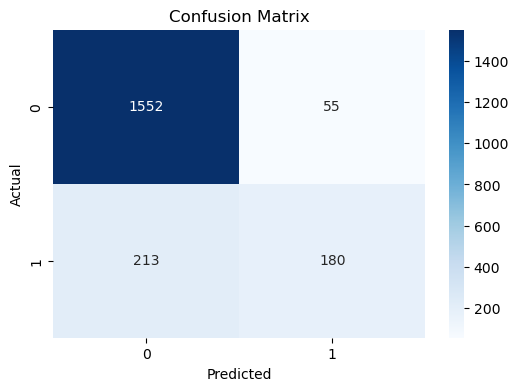

In [ ]:
# Step 12: Visualization Confusion Matrix 

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Report

In [16]:
# Step 13: Detailed performance report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



Feature Importance Analysis

In [17]:
# Step 14: Analyze Feature importance

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

              Feature  Importance
2                 Age    0.239783
8     EstimatedSalary    0.146638
0         CreditScore    0.144214
4             Balance    0.138613
5       NumOfProducts    0.130255
3              Tenure    0.082427
7      IsActiveMember    0.041110
9   Geography_Germany    0.025711
1              Gender    0.019258
6           HasCrCard    0.018722
10    Geography_Spain    0.013268


Feature Importance Visualization

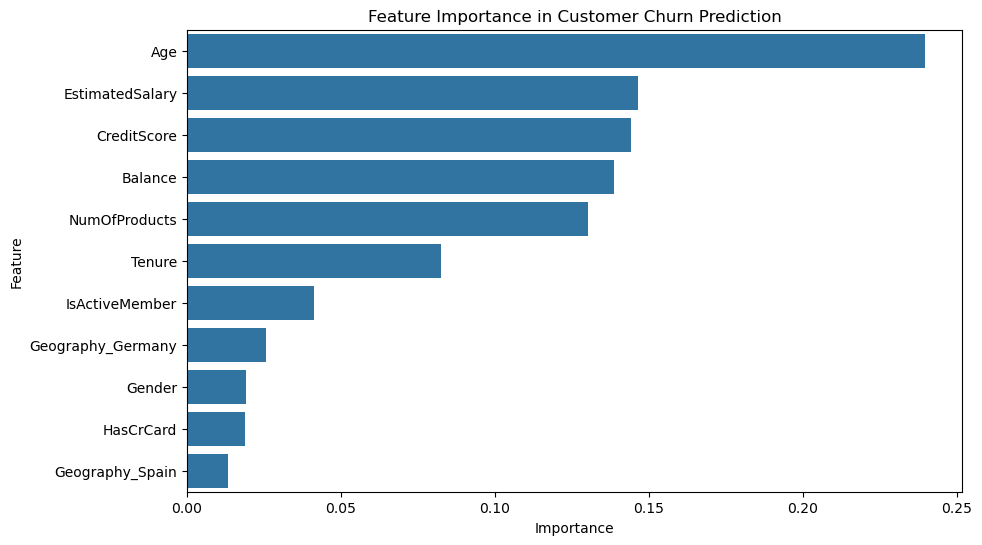

In [18]:
# Step 15: Feature importance graph

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance in Customer Churn Prediction")

plt.show()


Conclusion:

  Dataset successfully cleaned and prepared
  Gender and Geography encoded using Label Encoding and One-Hot Encoding
  Random Forest Classification model trained successfully
  Model evaluated using accuracy and confusion matrix
  Feature importance analysis identified key factors affecting customer churn
  Balance, Age, and Number of Products were among the most important features